# Synthetic Image Compression

In this notebook, we will explore various techniques for compressing synthetic images, taking advantage of a particular structure in the data. Our goal is to reduce a large number of pixels to a smaller set of parameters and preparing a graph representation of the image. The primary constraint on this compression is that the reconstruction should be lossless, meaning that we should be able to perfectly reconstruct the original image from the compressed representation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gbox as gb

## Create a target Image

(256, 256)


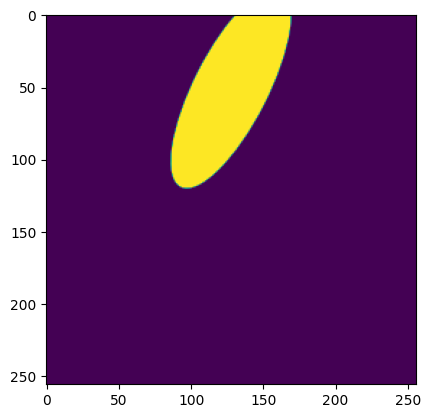

In [2]:
img_size = (256, 256)

ellipse = gb.Ellipse(3.0, 1.0, (0.0, 3.0), np.pi * 0.35)
ell_arr = ellipse.plot(
    shape_options={"facecolor": "white", "edgecolor": "None"},
    bg_options={"facecolor": "black", "edgecolor": "None"},
    image_options={"mode": "L", "size": img_size},
    bounds=[-5.0, -5.0, 5.0, 5.0],
    as_array=True,
)
print(ell_arr.shape)
plt.imshow(ell_arr)
plt.show()

## QuadTree Implementation

In [3]:
class QuadNode:
    def __init__(self, value=None, children=None):
        self.value = value
        self.children = children

    @property
    def is_leaf(self):
        return self.children is None


class QuadTreeBuilder:
    def __init__(self):
        self._num_nodes = 0
        self.leaves = []

    @property
    def num_nodes(self):
        n_leaves = len(self.leaves)
        return n_leaves if n_leaves != 0 else self._num_nodes        

    def build(self, img):
        if np.all(img == img[0, 0]):
            self._num_nodes += 1
            return QuadNode(value=img[0, 0])

        h, w = img.shape
        h2, w2 = h // 2, w // 2

        children = [
            self.build(img[:h2, :w2]),
            self.build(img[:h2, w2:]),
            self.build(img[h2:, :w2]),
            self.build(img[h2:, w2:]),
        ]

        # # ---- Hybrid Merge Step ----
        if all(child.is_leaf for child in children):
            vals = [child.value for child in children]
            if len(set(vals)) == 1:
                return QuadNode(value=vals[0])

        return QuadNode(children=children)

    def collect_leaves(self, node, x, y, size):
        if node.is_leaf:
            self.leaves.append((x, y, size, size, node.value))
            return

        half = size // 2

        self.collect_leaves(node.children[0], x, y, half)
        self.collect_leaves(node.children[1], x, y + half, half)
        self.collect_leaves(node.children[2], x + half, y, half)
        self.collect_leaves(node.children[3], x + half, y + half, half)

    def reconstruct(self, root_node, root_origin, root_size, target_size):
        if len(self.leaves) == 0:
            self.collect_leaves(root_node, *root_origin, root_size)
        reconstructed = np.zeros(target_size)
        for x, y, h, w, value in self.leaves:
            reconstructed[x : x + w, y : y + h] = value
        return reconstructed

    def visualise(self, root_node, root_origin, root_size, original_arr):
        if len(self.leaves) == 0:
            self.collect_leaves(root_node, *root_origin, root_size)

        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(original_arr, cmap="gray")
        axs[0].set_title("Original")

        axs[1].imshow(original_arr, cmap="gray")
        axs[1].set_title("Reconstruction")
        for x, y, w, h, _ in self.leaves:
            rect = plt.Rectangle(
                (y, x),
                w,
                h,
                edgecolor="y",
                facecolor="none",
                linewidth=1.0,
            )
            axs[1].add_patch(rect)

        plt.show()

    def merge_horizontal_and_vertical_blocks(self):
        # horizontal merging
        blocks = sorted(self.leaves, key=lambda b: (b[0], b[1]))
        merged = []

        prev = None

        for x, y, w, h, val in blocks:
            if prev is None:
                prev = [x, y, w, h, val]
                continue

            px, py, pw, ph, pv = prev

            if x == px and y == py + pw and ph == h and pv == val:
                prev[2] += w  # extend width
            else:
                merged.append(tuple(prev))
                prev = [x, y, w, h, val]

        if prev:
            merged.append(tuple(prev))

        # Vertical merging

        blocks = sorted(merged, key=lambda r: (r[1], r[0]))
        merged = []

        prev = None

        for x, y, w, h, val in blocks:
            if prev is None:
                prev = [x, y, w, h, val]
                continue

            px, py, pw, ph, pv = prev

            if y == py and x == px + ph and pw == w and pv == val:
                prev[3] += h
            else:
                merged.append(tuple(prev))
                prev = [x, y, w, h, val]

        if prev:
            merged.append(tuple(prev))

        self.leaves = merged

In [4]:
qtb = QuadTreeBuilder()
qroot_node = qtb.build(ell_arr)

Number of original image size: 65536

Number of nodes: 1078
Reduction in number of nodes: 98.355 %
Is reconstructed img same?:  True


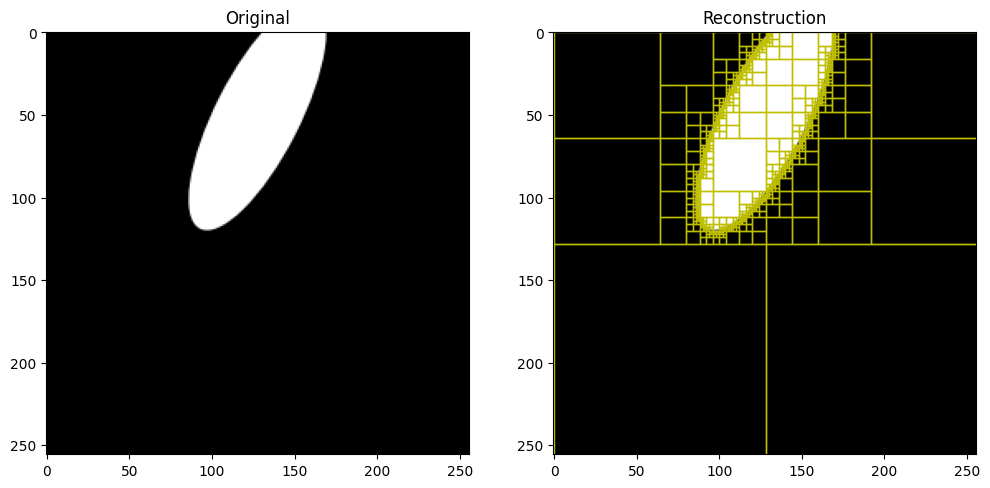

Summary after horizontal and vertical merging...

Number of nodes: 634
Reduction in number of nodes: 99.033 %
Is reconstructed img same?:  True


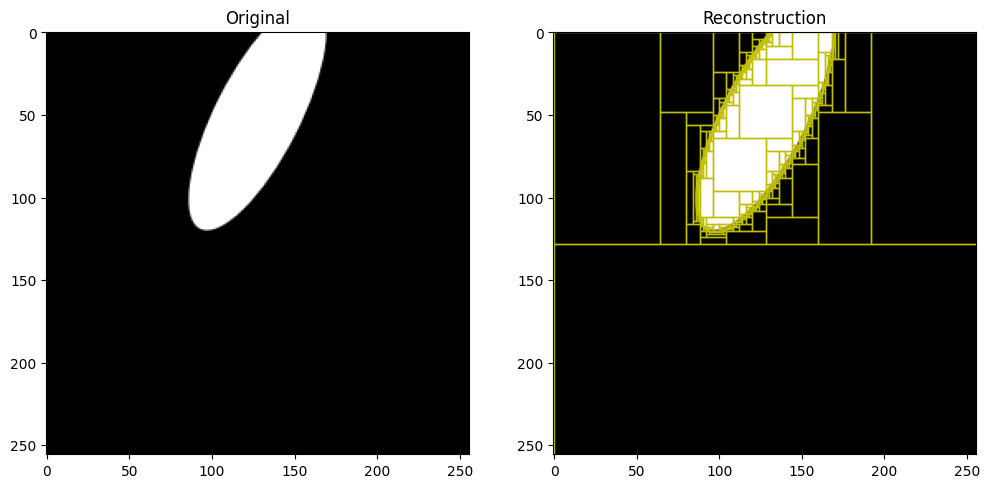

In [5]:
num_original_nodes = ell_arr.size
print(f"Number of original image size: {num_original_nodes}")

pct_reduction = (1.0 - (qtb.num_nodes / num_original_nodes)) * 100
recon = qtb.reconstruct(qroot_node, (0, 0), max(img_size), img_size)
is_same = np.all(recon == ell_arr)
print(f"\nNumber of nodes: {qtb.num_nodes}")
print(f"Reduction in number of nodes: {pct_reduction:.3f} %")
print("Is reconstructed img same?: ", is_same)
qtb.visualise(qroot_node, (0, 0), max(img_size), ell_arr)

print("Summary after horizontal and vertical merging...")
qtb.merge_horizontal_and_vertical_blocks()

pct_reduction = (1.0 - (qtb.num_nodes / num_original_nodes)) * 100
recon = qtb.reconstruct(qroot_node, (0, 0), max(img_size), img_size)
is_same = np.all(recon == ell_arr)
print(f"\nNumber of nodes: {qtb.num_nodes}")
print(f"Reduction in number of nodes: {pct_reduction:.3f} %")
print("Is reconstructed img same?: ", is_same)
qtb.visualise(qroot_node, (0, 0), max(img_size), ell_arr)


In [6]:
def get_nodes_(
    aspect_ratio, area_fraction, num_angles=10, image_size=(256, 256)
):
    angles = np.linspace(0.0, np.pi * 0.5, num_angles)
    bounds = [-5.0, -5.0, 5.0, 5.0]
    ell_centre = (0.0, 0.0)
    area = (bounds[2] - bounds[0]) * (bounds[3] - bounds[1])

    results = []
    b = np.sqrt((area_fraction * area) / (np.pi * aspect_ratio))
    a = aspect_ratio * b
    for a_ang in angles:
        ellipse = gb.Ellipse(a, b, ell_centre, a_ang)
        ell_arr = ellipse.plot(
            shape_options={"facecolor": "white", "edgecolor": "None"},
            bg_options={"facecolor": "black", "edgecolor": "None"},
            image_options={"mode": "L", "size": image_size},
            bounds=bounds,
            as_array=True,
        )

        qtb = QuadTreeBuilder()
        qroot_node = qtb.build(ell_arr)
        assert np.all(
            qtb.reconstruct(qroot_node, (0, 0), max(image_size), image_size)
            == ell_arr
        )
        a_result = [np.rad2deg(a_ang), qtb.num_nodes]

        qtb.merge_horizontal_and_vertical_blocks()
        assert np.all(
            qtb.reconstruct(qroot_node, (0, 0), max(image_size), image_size)
            == ell_arr
        )
        a_result.append(qtb.num_nodes)
        results.append(a_result)

    results = np.array(results, dtype=np.float64)
    return results

In [7]:
aspect_ratios = (1.0, 2.0, 5.0)
area_fractions = (0.2, 0.5, 0.8)
image_size = (256, 256)
collection = {}
for i, aar in enumerate(aspect_ratios):
    for j, aaf in enumerate(area_fractions):
        collection[(aar, aaf)] = get_nodes_(aar, aaf, 100, image_size)

## Variation of reduced nodes fraction at various aspect ratios, area fractions and ellipse orientations

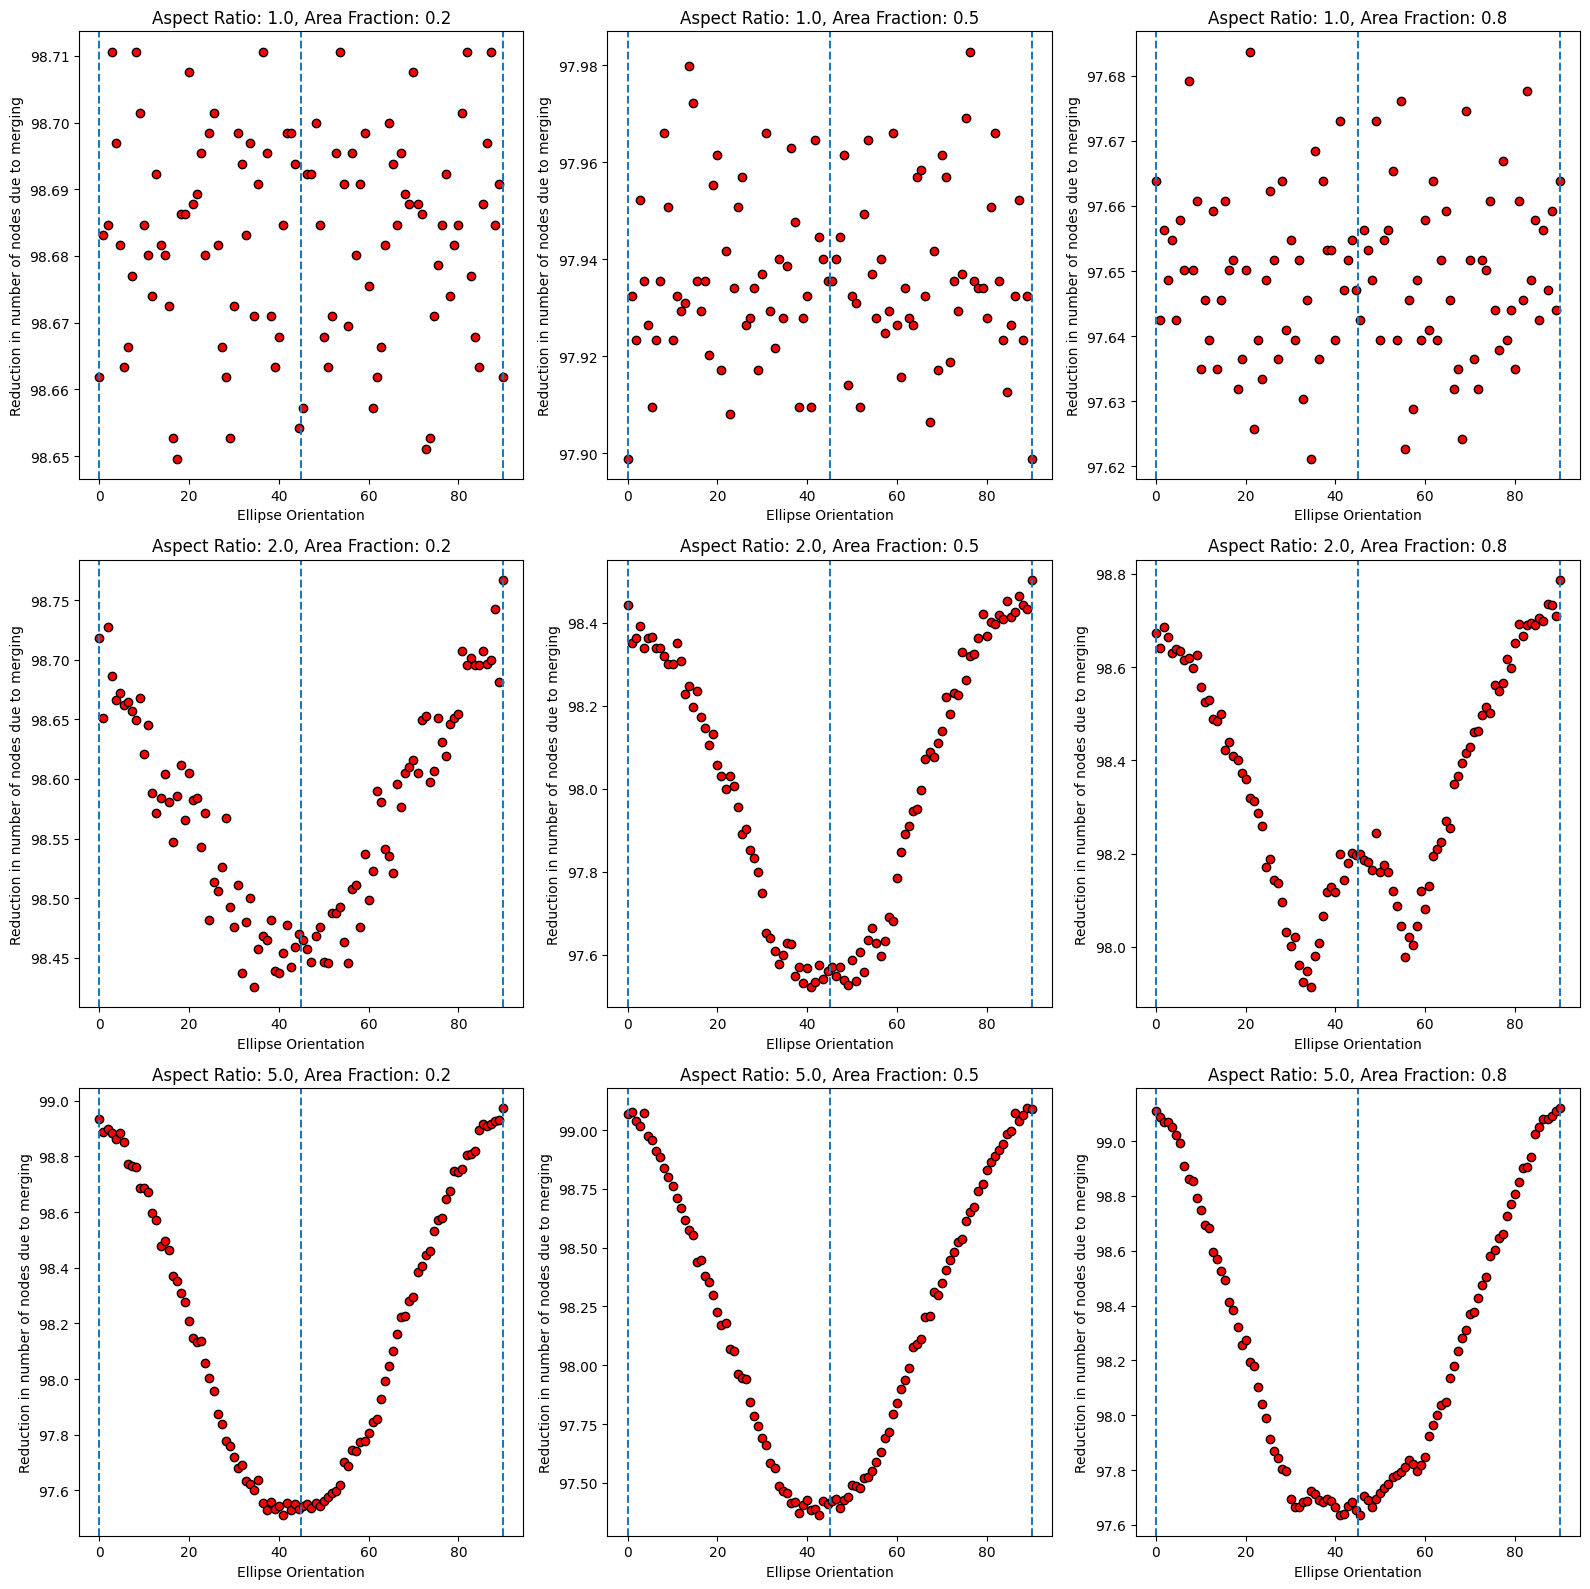

In [10]:
num_original_nodes = image_size[0] * image_size[1]

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
for i, aar in enumerate(aspect_ratios):
    for j, aaf in enumerate(area_fractions):
        node_info = collection[(aar, aaf)]
        x = node_info[:, 0]
        y = (1.0 - node_info[:, 2] / num_original_nodes) * 100
        axs[i, j].scatter(x, y, c='r', edgecolors='k')
        axs[i, j].axvline(x=0.0, linestyle="dashed")
        axs[i, j].axvline(x=45.0, linestyle="dashed")
        axs[i, j].axvline(x=90.0, linestyle="dashed")
        axs[i, j].set_title(f"Aspect Ratio: {aar}, Area Fraction: {aaf}")
        axs[i, j].set_xlabel("Ellipse Orientation")
        axs[i, j].set_ylabel("Reduction in number of nodes due to merging")
plt.tight_layout()
plt.show()

In the above plot, we can see that reduction in nodes is higher at ellipse orientations closer to 0 and 90 degrees, and lower at orientations closer to 45 degrees.

## Adaptive Rectangular Partitioning

> Coming Soon
>